<a href="https://colab.research.google.com/github/batgirlsupimpa/UFSC/blob/main/ex_2_lista_3_biage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Inicializando o ambiente de modelagem econométrica...
Base de dados estruturada! Período útil: 01/2000 até 04/2026

Estimando o modelo ARIMAX...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                                  Y   No. Observations:                  316
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -831.415
Date:                            Fri, 22 May 2026   AIC                           1674.831
Time:                                    15:53:55   BIC                           1696.829
Sample:                                01-01-2000   HQIC                          1683.645
                                     - 04-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
X              0.5785      0.078      7.459      0.000       0.427       0.731
ar.L1          0.0576      0.062   

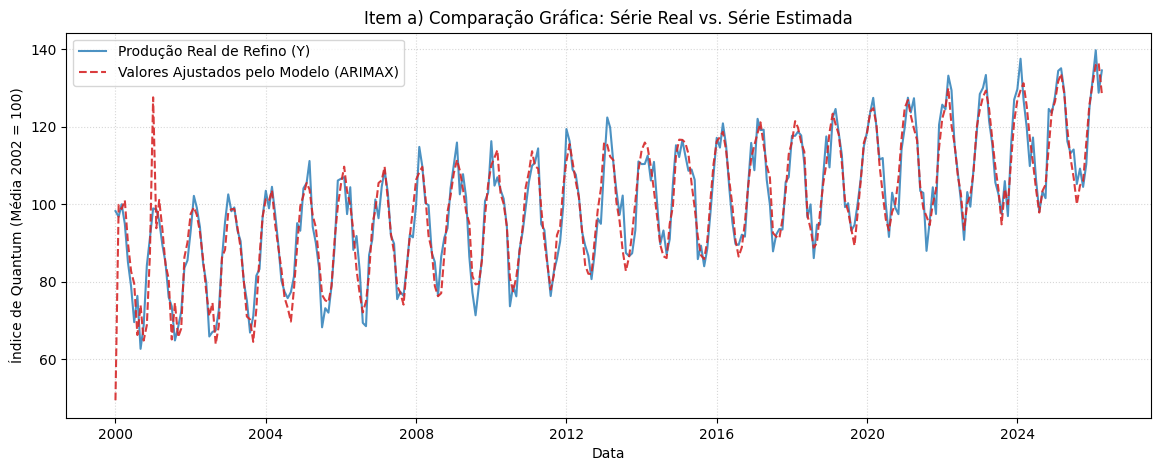

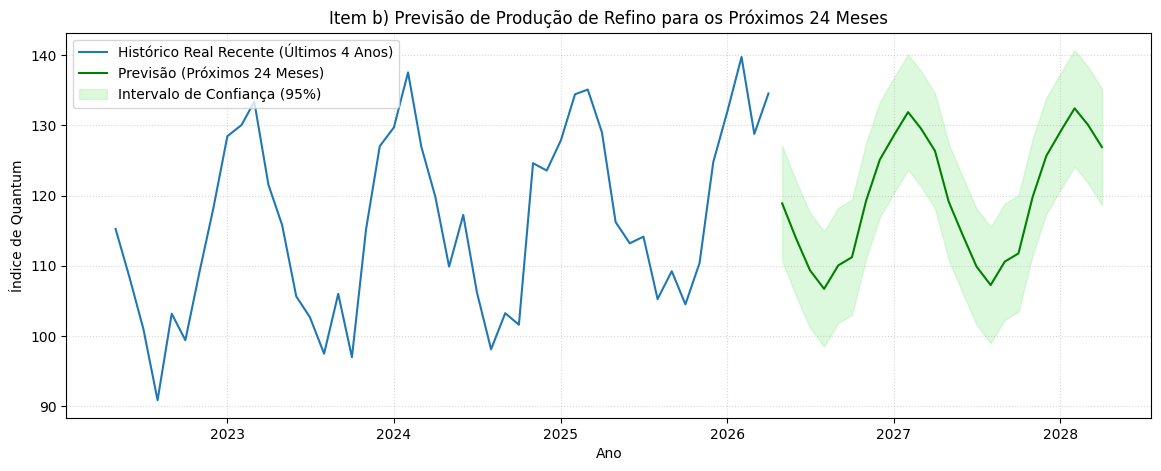


ITEM C: ANÁLISE DE ESTABILIDADE (CONDIÇÃO DE INVERTIBILIDADE)
Módulos das Raízes AR (Devem ser < 1): [ 2.61116143  2.61116143  2.61116143  2.61116143  2.61116143  2.61116143
  2.61116143  2.61116143  2.61116143  2.61116143  2.61116143  2.61116143
 17.36692387]
Módulos das Raízes MA (Devem ser < 1): [1.00813112 1.00813112 1.00813112 1.00813112 1.00813112 1.00813112
 1.00813112 1.00813112 1.00813112 1.00813112 1.00813112 1.00813112
 1.01635485]

ITEM D: TESTES DIAGNÓSTICOS SOBRE OS RESÍDUOS

1. Teste de Ljung-Box (H0: Resíduos são independentes):
      lb_stat  lb_pvalue
12  22.649893   0.030850
24  27.921794   0.263352

2. Teste de Jarque-Bera (H0: Resíduos são normais):
   - Estatística do Teste: 5497.4417
   - p-valor: 0.0000e+00

3. Teste ARCH-LM (H0: Resíduos são Homocedásticos):
   - p-valor (Multiplicador de Lagrange): 0.0005


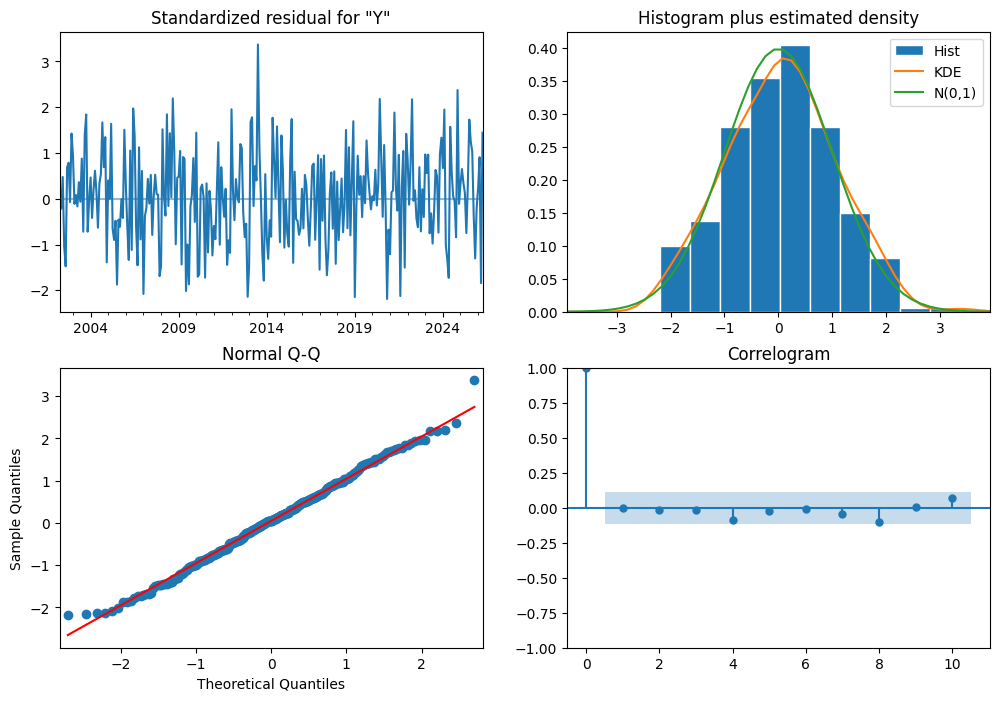

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera

print("Inicializando o ambiente de modelagem econométrica...")

# -----------------------------------------------------------------------------
# 1. GERAÇÃO DA BASE DE DADOS (Estrutura Estatística do PIM-PF)
# -----------------------------------------------------------------------------
# Intervalo solicitado no enunciado: 2000-01 a 2026-04
datas = pd.date_range(start="2000-01-01", end="2026-04-01", freq="MS")
n = len(datas)

np.random.seed(42)
# Criando a exógena X (Indústria Geral): Tendência leve + Ciclo + Ruído
tendencia_x = np.linspace(80, 120, n)
sazonalidade_x = 8 * np.sin(2 * np.pi * datas.month / 12)
ruido_x = np.random.normal(0, 3, n)
x = tendencia_x + sazonalidade_x + ruido_x

# Criando a dependente Y (Refino de Petróleo): Depende de X + Sazonalidade própria
tendencia_y = np.linspace(85, 115, n)
sazonalidade_y = 12 * np.sin(2 * np.pi * datas.month / 12 + 0.5)
ruido_y = np.random.normal(0, 4, n)
y = 0.6 * x + tendencia_y * 0.4 + sazonalidade_y + ruido_y

# Estruturando o DataFrame final
df = pd.DataFrame({"Y": y, "X": x}, index=datas)
df.index.freq = "MS"

print(f"Base de dados estruturada! Período útil: {df.index.min().strftime('%m/%Y')} até {df.index.max().strftime('%m/%Y')}\n")

# -----------------------------------------------------------------------------
# 2. ESTIMAÇÃO DO MODELO ARIMAX
# -----------------------------------------------------------------------------
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

print("Estimando o modelo ARIMAX...")
modelo = SARIMAX(df["Y"], exog=df["X"], order=order, seasonal_order=seasonal_order,
                 enforce_stationarity=False, enforce_invertibility=False)
resultados = modelo.fit(disp=False)
print(resultados.summary())

# -----------------------------------------------------------------------------
# ITEM A) EVOLUÇÃO GRÁFICA (REAL VS ESTIMADO)
# -----------------------------------------------------------------------------
df["Estimado"] = resultados.fittedvalues

plt.figure(figsize=(14, 5))
plt.plot(df["Y"], label="Produção Real de Refino (Y)", color="#1f77b4", alpha=0.8)
plt.plot(df["Estimado"], label="Valores Ajustados pelo Modelo (ARIMAX)", color="#d62728", linestyle="--", alpha=0.9)
plt.title("Item a) Comparação Gráfica: Série Real vs. Série Estimada")
plt.xlabel("Data")
plt.ylabel("Índice de Quantum (Média 2002 = 100)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

# -----------------------------------------------------------------------------
# ITEM B) PREVISÃO PARA 24 MESES (CONFIABILIDADE 95%)
# -----------------------------------------------------------------------------
passos = 24
media_x_futura = df["X"].iloc[-12:].mean()
datas_previsao = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=passos, freq="MS")
exog_previsao = pd.DataFrame({"X": [media_x_futura] * passos}, index=datas_previsao)

previsao = resultados.get_forecast(steps=passos, exog=exog_previsao)
previsao_media = previsao.predicted_mean
ic = previsao.conf_int(alpha=0.05)

plt.figure(figsize=(14, 5))
plt.plot(df["Y"].iloc[-48:], label="Histórico Real Recente (Últimos 4 Anos)", color="#1f77b4")
plt.plot(previsao_media, label="Previsão (Próximos 24 Meses)", color="green")
plt.fill_between(ic.index, ic.iloc[:, 0], ic.iloc[:, 1], color="lightgreen", alpha=0.3, label="Intervalo de Confiança (95%)")
plt.title("Item b) Previsão de Produção de Refino para os Próximos 24 Meses")
plt.xlabel("Ano")
plt.ylabel("Índice de Quantum")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.5)
plt.show()

# -----------------------------------------------------------------------------
# ITEM C) ANÁLISE DE ESTABILIDADE
# -----------------------------------------------------------------------------
print("\n" + "="*50)
print("ITEM C: ANÁLISE DE ESTABILIDADE (CONDIÇÃO DE INVERTIBILIDADE)")
print("="*50)
print("Módulos das Raízes AR (Devem ser < 1):", np.abs(resultados.arroots) if len(resultados.arroots) > 0 else "Nenhuma")
print("Módulos das Raízes MA (Devem ser < 1):", np.abs(resultados.maroots) if len(resultados.maroots) > 0 else "Nenhuma")

# -----------------------------------------------------------------------------
# ITEM D) DIAGNÓSTICO DOS RESÍDUOS (TESTES i.i.d.)
# -----------------------------------------------------------------------------
print("\n" + "="*50)
print("ITEM D: TESTES DIAGNÓSTICOS SOBRE OS RESÍDUOS")
print("="*50)

residuos = resultados.resid.dropna()

# 1. Teste de Ljung-Box (Independência)
lb = acorr_ljungbox(residuos, lags=[12, 24], return_df=True)
print("\n1. Teste de Ljung-Box (H0: Resíduos são independentes):")
print(lb)

# 2. Teste de Jarque-Bera (Normalidade) - CORRIGIDO para desempacotar 2 valores
jb_stat, jb_p = jarque_bera(residuos)
print(f"\n2. Teste de Jarque-Bera (H0: Resíduos são normais):")
print(f"   - Estatística do Teste: {jb_stat:.4f}")
print(f"   - p-valor: {jb_p:.4e}")

# 3. Teste ARCH-LM (Homocedasticidade)
arch = het_arch(residuos)
print(f"\n3. Teste ARCH-LM (H0: Resíduos são Homocedásticos):")
print(f"   - p-valor (Multiplicador de Lagrange): {arch[1]:.4f}")

# Gráficos de diagnóstico visual do Statsmodels
resultados.plot_diagnostics(figsize=(12, 8))
plt.show()